# Non-local correlators and Green's functions

The same Chebyshev expansion gives non-local correlators/Green's functions
$G_{ij}(\omega)=\langle i|(\omega-H)^{-1}|j\rangle$ between two different sites, without ever
inverting a matrix: `kpm.dm_ij_energy`, seeded with the pair of sites instead of a single delta
vector. Cross-checked below against the exact Green's function from direct matrix inversion
(`correlator.dm_ij_energy`).

KPM time = 13.550s, exact-inversion time = 14.507s


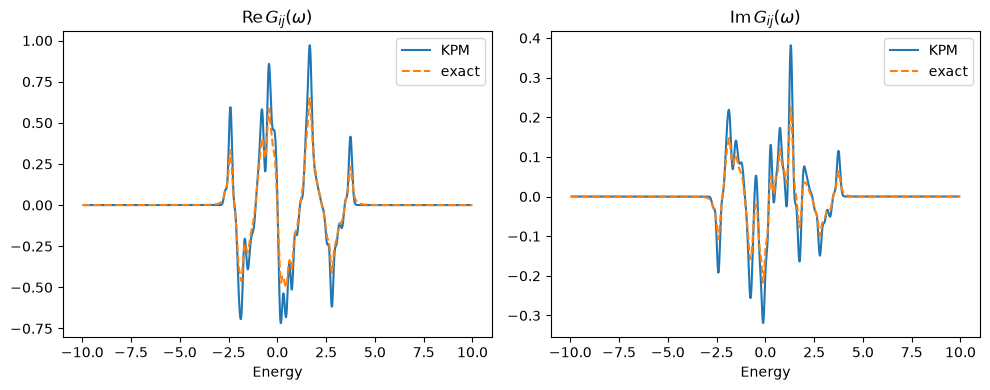

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import correlator, kpm
import time

g = geometry.chain()
g = g.get_supercell(100)
g.dimensionality = 0
h = g.get_hamiltonian()
h.add_rashba(0.5)
h.add_zeeman([0.,1.,0.])
np.random.seed(0)
h.intra += np.diag(np.random.random(h.intra.shape[0])) # weak onsite disorder

i,j = 0,9
t0 = time.time()
(x,y) = kpm.dm_ij_energy(h.intra,npol=200,i=i,j=j,ne=1000)
t1 = time.time()
(x2,y2) = correlator.dm_ij_energy(h.intra,i=i,j=j,delta=0.1,ne=1000)
t2 = time.time()
print(f"KPM time = {t1-t0:.3f}s, exact-inversion time = {t2-t1:.3f}s")

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(x,y.real,label="KPM") ; axs[0].plot(x2,y2.real,"--",label="exact")
axs[0].set_title(r"Re$\,G_{ij}(\omega)$") ; axs[0].set_xlabel("Energy") ; axs[0].legend()
axs[1].plot(x,y.imag,label="KPM") ; axs[1].plot(x2,y2.imag,"--",label="exact")
axs[1].set_title(r"Im$\,G_{ij}(\omega)$") ; axs[1].set_xlabel("Energy") ; axs[1].legend()
plt.tight_layout()
plt.show()

The same expansion between the first site of the chain and each of the following ones gives a map
of the non-local Green's function $|G_{0j}(\omega)|$ as a function of the distance and of the
energy, summed over the spin of site $j$. It vanishes outside the band, and inside it shows the
interference pattern of the states that propagate away from the end of the chain.

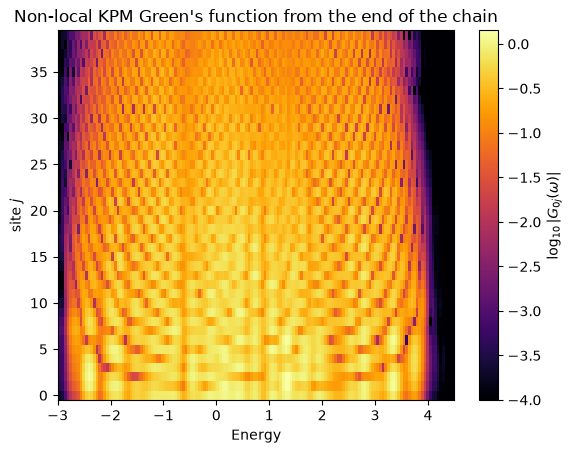

In [2]:
ns = np.arange(40) # sites of the chain, starting from the end
gmap = []
for n in ns: # sum over the two spin components of site n
    (x,g_up) = kpm.dm_ij_energy(h.intra,npol=200,i=0,j=2*n,ne=400)
    (x,g_dn) = kpm.dm_ij_energy(h.intra,npol=200,i=0,j=2*n+1,ne=400)
    gmap.append(np.sqrt(np.abs(g_up)**2 + np.abs(g_dn)**2))
gmap = np.array(gmap)

plt.pcolormesh(x,ns,np.log10(gmap+1e-6),cmap="inferno",vmin=-4,shading="auto")
plt.colorbar(label=r"$\log_{10}|G_{0j}(\omega)|$")
plt.xlim(-3.,4.5)
plt.xlabel("Energy") ; plt.ylabel("site $j$")
plt.title("Non-local KPM Green's function from the end of the chain")
plt.show()